In [19]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers, models, regularizers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load Data

In [20]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

X_train = X_train.reshape(-1, 28, 28, 1).astype("float32") / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1).astype("float32") / 255.0

NUM_CLASSES = np.unique(y_train).shape[0]
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

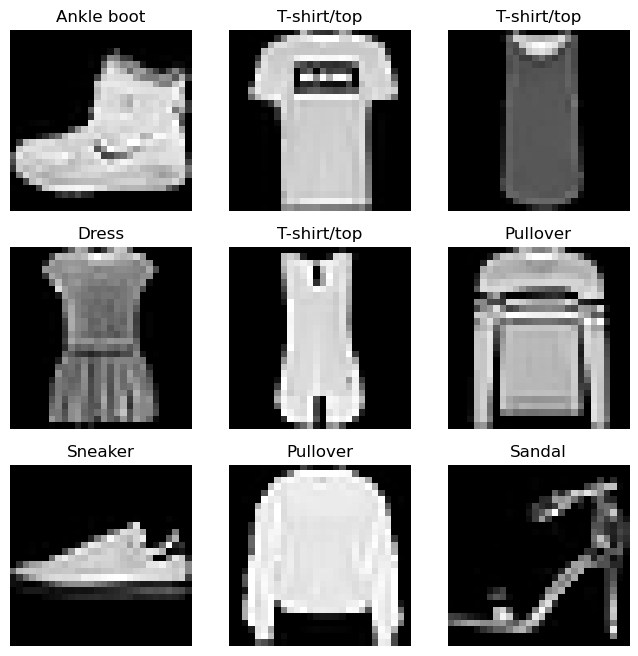

In [21]:
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(CLASS_NAMES[y_train[i]])
    plt.axis("off")

plt.show()

# Helpers

In [22]:
def plot_training(history, model_name="Model"):
    fig, axes = plt.subplots(figsize=(12, 4), nrows=1, ncols=2)
    axes = axes.flatten()

    axes[0].plot(history["sparse_categorical_accuracy"], label="Train Accuracy")
    axes[0].plot(history["val_sparse_categorical_accuracy"], label="Val Accuracy")

    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Sparse Categorical Accuracy")

    axes[0].set_title(f"{model_name} Accuracy")
    axes[0].legend()

    axes[1].plot(history["loss"], label="Train Loss")
    axes[1].plot(history["val_loss"], label="Val Loss")

    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")

    axes[1].set_title(f"{model_name} Loss")
    axes[1].legend()

    plt.show()

In [23]:
def plot_cm(model):
    y_preds = model.predict(X_test).argmax(axis=1)
    cm = confusion_matrix(y_test, y_preds)

    fig, ax = plt.subplots(figsize=(12, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax)
    plt.show()

In [24]:
def show(name, t):
    """vibe coded function for visualizing activations"""
    if t.ndim == 4:                      # (1, H, W, C) feature maps
        fmap = t[0]
        n = fmap.shape[-1]
        cols = 8
        rows = int(np.ceil(n / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(12, rows + 0.5))
        for i, ax in enumerate(axes.flat):
            if i < n:
                ax.imshow(fmap[:, :, i], cmap="viridis")
            ax.axis("off")
        fig.suptitle(f"{name}  {t.shape}")
    else:                                # (1, features) vector
        plt.figure(figsize=(12, 2))
        plt.bar(range(t.shape[-1]), t[0])
        plt.title(f"{name}  {t.shape}")
    plt.show()

In [25]:
def trace_input(sample, model):
    activations = [("input", sample)]

    x = sample
    for layer in model.layers:
        x = layer(x)
        activations.append((layer.name, np.array(x)))

    for name, t in activations:
        show(name, t)

# Shared Model Config

In [26]:
tf.random.set_seed(42)

In [27]:
sample_sneaker =  X_test[0:1] # (1, 28, 28, 1)
sample_pullover = X_test[1:2] # (1, 28, 28, 1)
sample_trouser = X_test[2:3] # (1, 28, 28, 1)

In [28]:
# so that we can reuse but still init a new class each time
def make_callbacks():
   return [
        tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",                         # watch validation loss
        patience=3,                                 # stop if no improvement for 3 epochs
        restore_best_weights=True                   # revert to best model after stopping
    )
   ]

In [29]:
model_results = []

# Benchmark Model

## Model

In [30]:
bench = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=32,
                  kernel_size=(4, 4),
                  activation="relu",
                  padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

bench.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.sparse_categorical_accuracy]) # just balanced_accuracy

bench_history = bench.fit(
    x=X_train,
    y=y_train,
    validation_split=0.10,
    epochs=20,
    callbacks=make_callbacks()
)

bench_test_loss, bench_test_accuracy = bench.evaluate(X_test, y_test)
model_results.append({ "name": "Benchmark", "loss": bench_test_loss, "acc": bench_test_accuracy })

print(f"bench test accuracy: {bench_test_accuracy}")

Epoch 1/20


I0000 00:00:1780109807.755874     934 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122792__.21


1678/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5404 - sparse_categorical_accuracy: 0.8080

I0000 00:00:1780109815.072941     935 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_122792__.21


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.4049 - sparse_categorical_accuracy: 0.8555 - val_loss: 0.3108 - val_sparse_categorical_accuracy: 0.8893
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.2746 - sparse_categorical_accuracy: 0.9012 - val_loss: 0.2715 - val_sparse_categorical_accuracy: 0.9048
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - loss: 0.2281 - sparse_categorical_accuracy: 0.9169 - val_loss: 0.2588 - val_sparse_categorical_accuracy: 0.9090
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - loss: 0.1942 - sparse_categorical_accuracy: 0.9297 - val_loss: 0.2590 - val_sparse_categorical_accuracy: 0.9117
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.1664 - sparse_categorical_accuracy: 0.9389 - val_loss: 0.2701 - val_sparse_categorical_accuracy: 0.9097
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1419 - sparse_categorical_accuracy: 0.9484 - val_loss: 0.2953 - val_sparse_categorical_accuracy: 0.908

## Visualizations

### Training

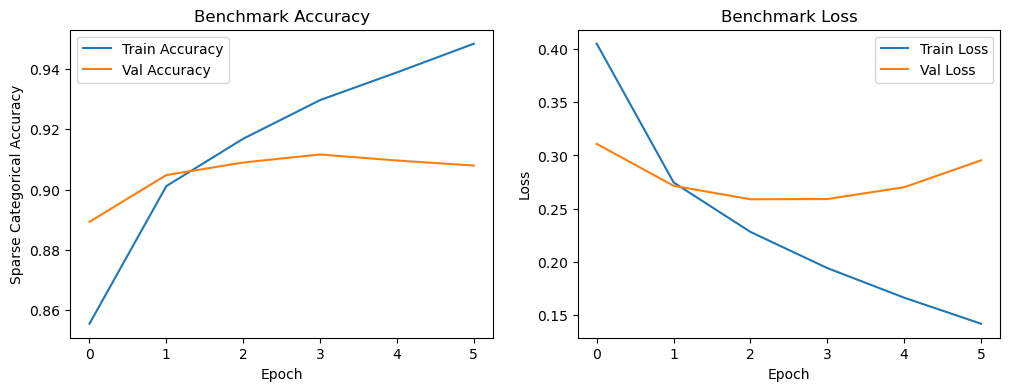

In [31]:
plot_training(bench_history.history, "Benchmark")

### Tracing Layers

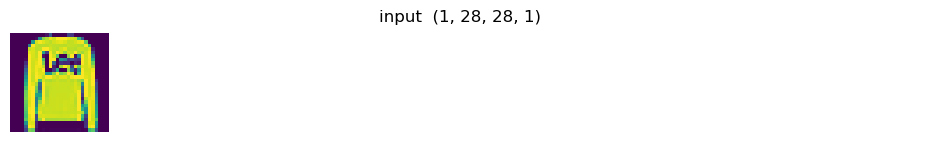

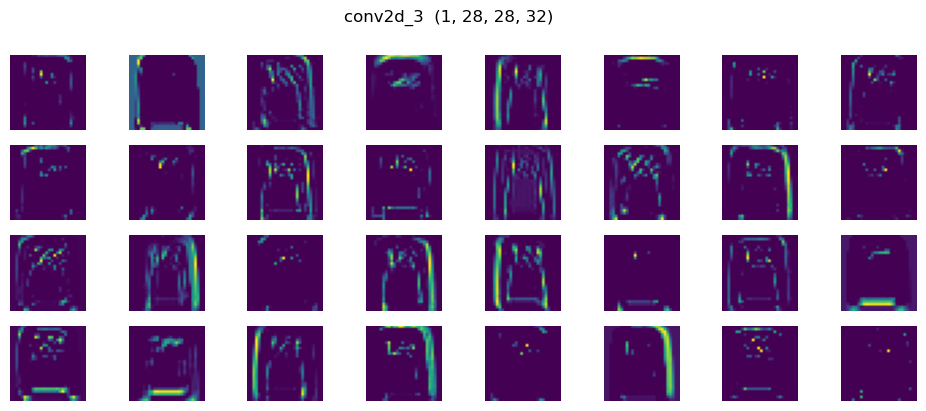

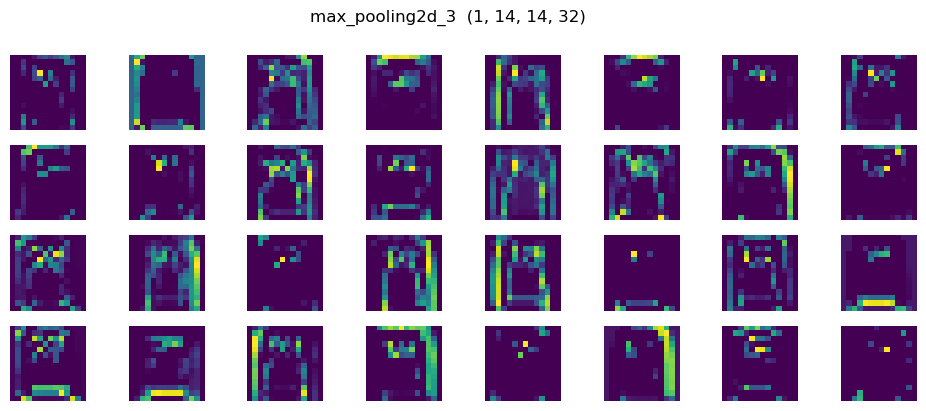

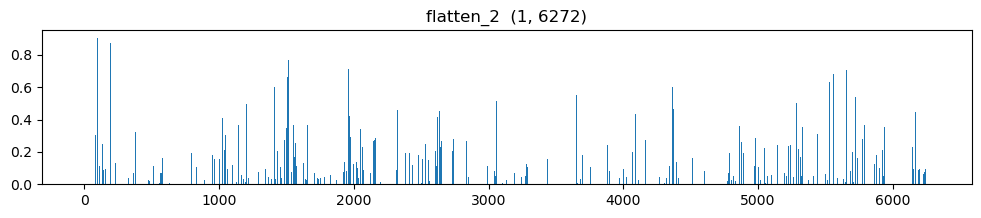

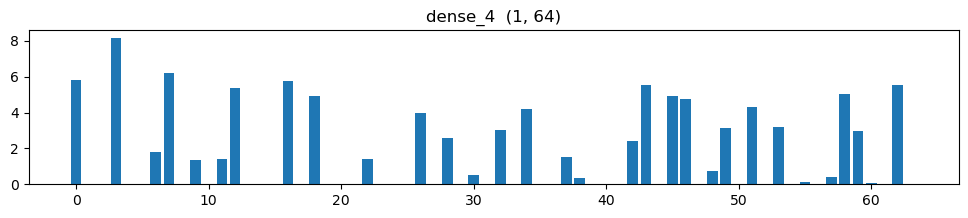

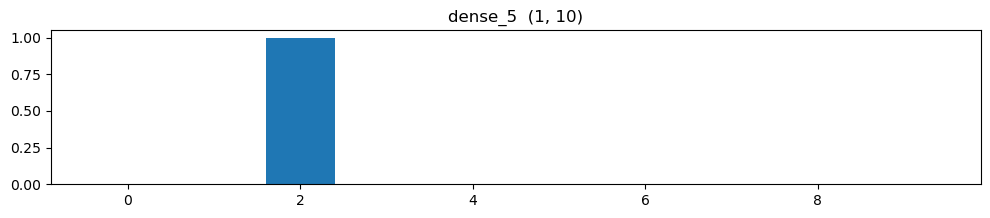

In [32]:
trace_input(sample_pullover, bench)

### Errors

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


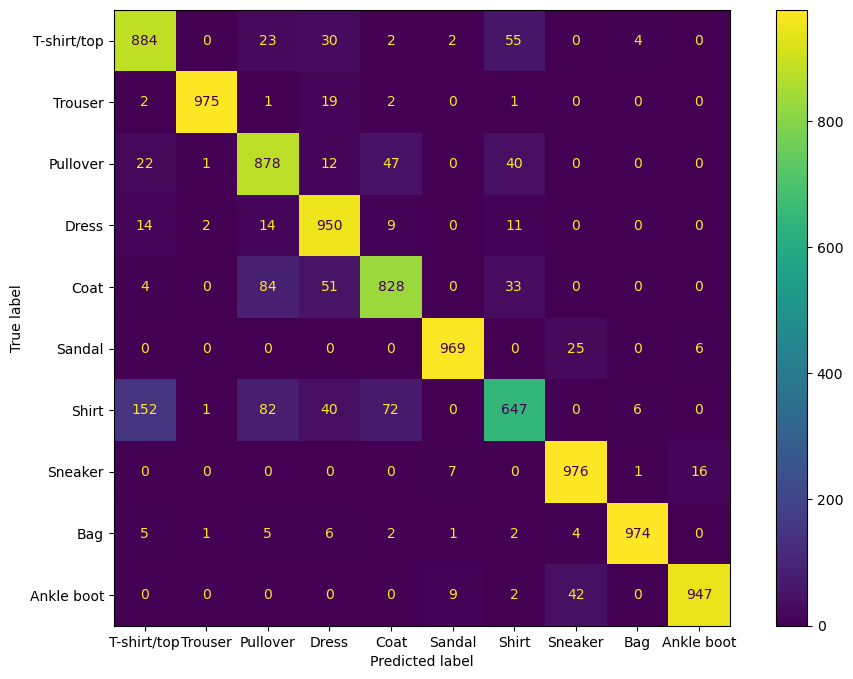

In [33]:
plot_cm(bench)

- Confuses _SHIRT_ for T-Shirt/Top, Pullover, Dress, and Pullover.
- Confuses _COAT_ for Pullover and Dress.

**Benchmark model clearly understands the torso shape** OR **what isn't torso-shaped**.

# Experiment 1: Convolution

I am not yet sure what is causing the model confusion. Tracing the benchmark activations, it seems like there is too much noise in the image right before it gets flattened.

More specifically: With only one convolution layer, by the time we flatten, we will have a 6,272 features which get fed into a 64 neuron dense layer. Adding more convolution layers will reduce the number of features and ideally noise.

## Model (A)

2x Convolution + MaxPooling layers

In [34]:
exp_1a = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=32,
                  kernel_size=(4, 4),
                  activation="relu",
                  padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    # add a second convolution layer
    layers.Conv2D(filters=64,           # increase number of filters...
                  kernel_size=(2, 2),   # ...but reduce window size
                  activation="relu",
                  padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

exp_1a.compile(optimizer=keras.optimizers.Adam(),
               loss=keras.losses.SparseCategoricalCrossentropy(),
               metrics=[keras.metrics.sparse_categorical_accuracy]) # just balanced_accuracy

exp_1a_history = exp_1a.fit(
    x=X_train,
    y=y_train,
    validation_split=0.10,
    epochs=20,
    callbacks=make_callbacks()
)

exp_1a_test_loss, exp_1a_test_accuracy = exp_1a.evaluate(X_test, y_test)
model_results.append({
    "name": "Experiment 1a",
    "loss": exp_1a_test_loss,
    "acc": exp_1a_test_accuracy,
    "notes": "add second conv layer"
})

print(f"exp_1a test accuracy: {exp_1a_test_accuracy}")

Epoch 1/20


I0000 00:00:1780109884.716789     934 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_173564__.30


1678/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6041 - sparse_categorical_accuracy: 0.7837

I0000 00:00:1780109891.832930     933 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_173564__.30


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.4341 - sparse_categorical_accuracy: 0.8447 - val_loss: 0.3185 - val_sparse_categorical_accuracy: 0.8842
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2893 - sparse_categorical_accuracy: 0.8954 - val_loss: 0.2749 - val_sparse_categorical_accuracy: 0.9017
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2457 - sparse_categorical_accuracy: 0.9110 - val_loss: 0.2573 - val_sparse_categorical_accuracy: 0.9068
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2119 - sparse_categorical_accuracy: 0.9231 - val_loss: 0.2483 - val_sparse_categorical_accuracy: 0.9105
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1846 - sparse_categorical_accuracy: 0.9328 - val_loss: 0.2557 - val_sparse_categorical_accuracy: 0.9117
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1591 - sparse_categorical_accuracy: 0.9430 - val_loss: 0.2700 - val_sparse_categorical_accuracy: 0.9092
Ep

## Visualizations (A)

### Training

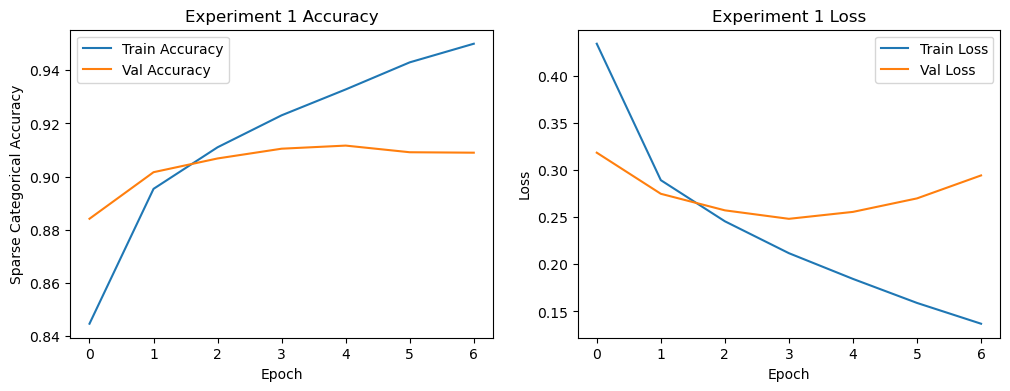

In [35]:
plot_training(exp_1a_history.history, "Experiment 1")

Validation loss curve looks better than the benchmark: it doesn't trend up after the plateau. However, the continued decrease in training loss along with improvements to train accuracy after validation metrics have leveled tells me that the model is probably overfitting.

### Tracing Layers

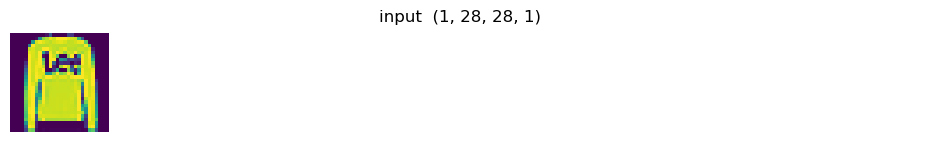

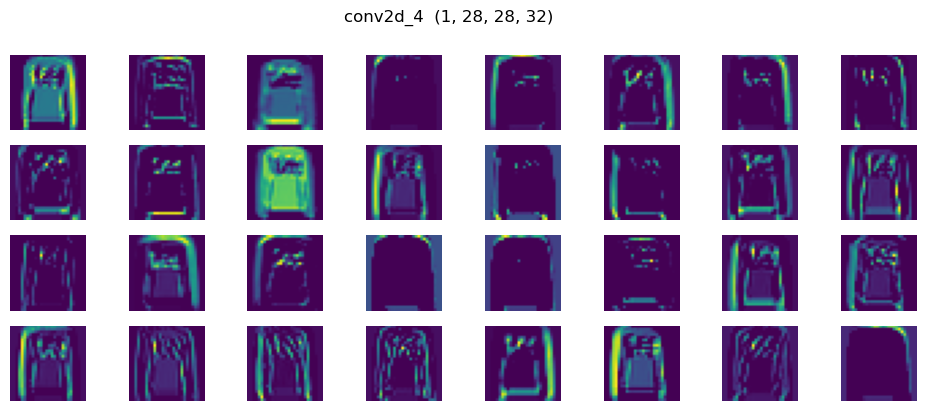

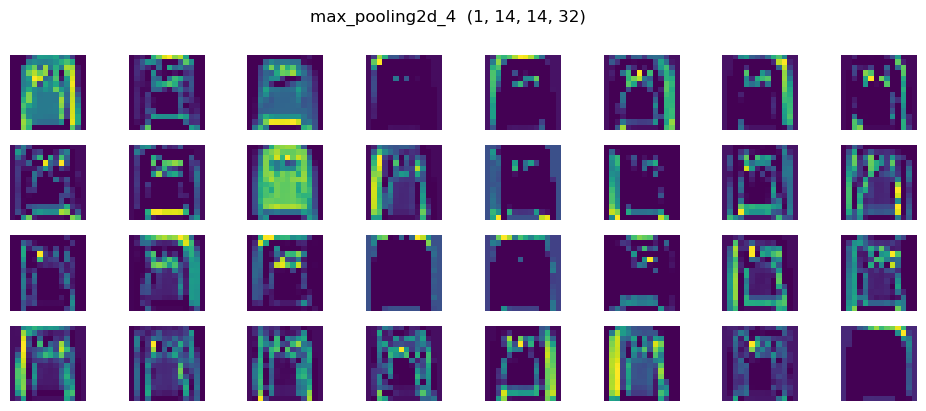

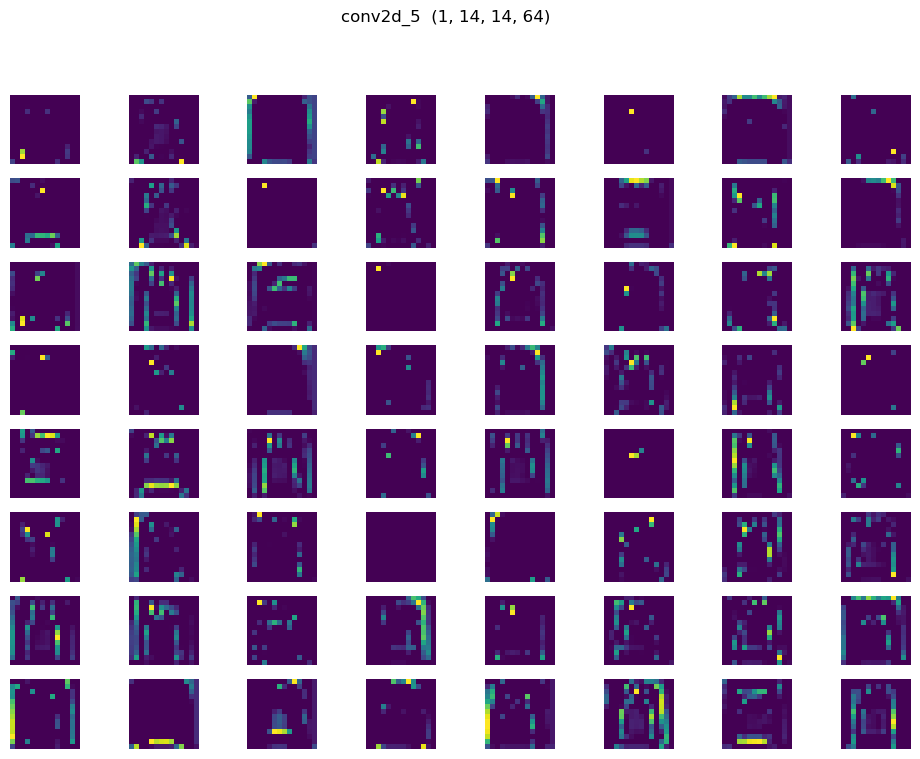

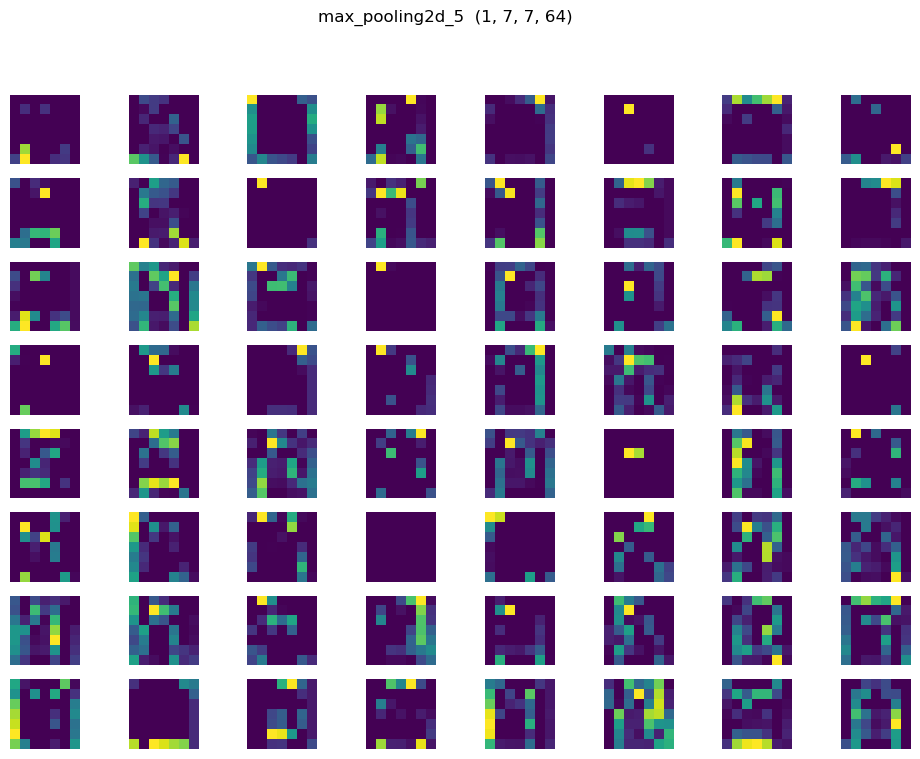

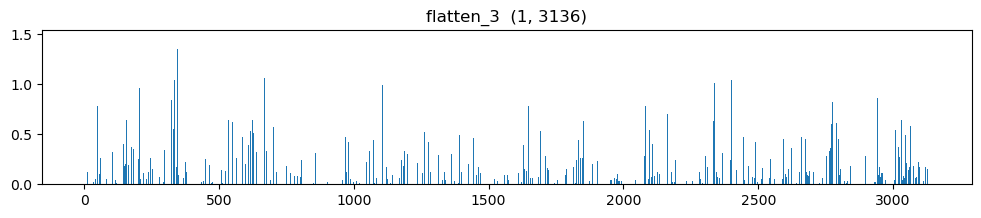

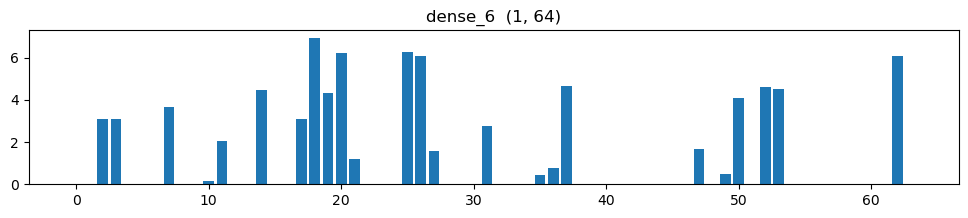

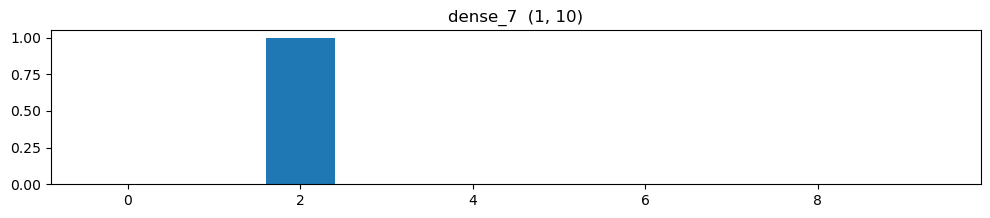

In [36]:
trace_input(sample_pullover, exp_1a)

### Errors

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


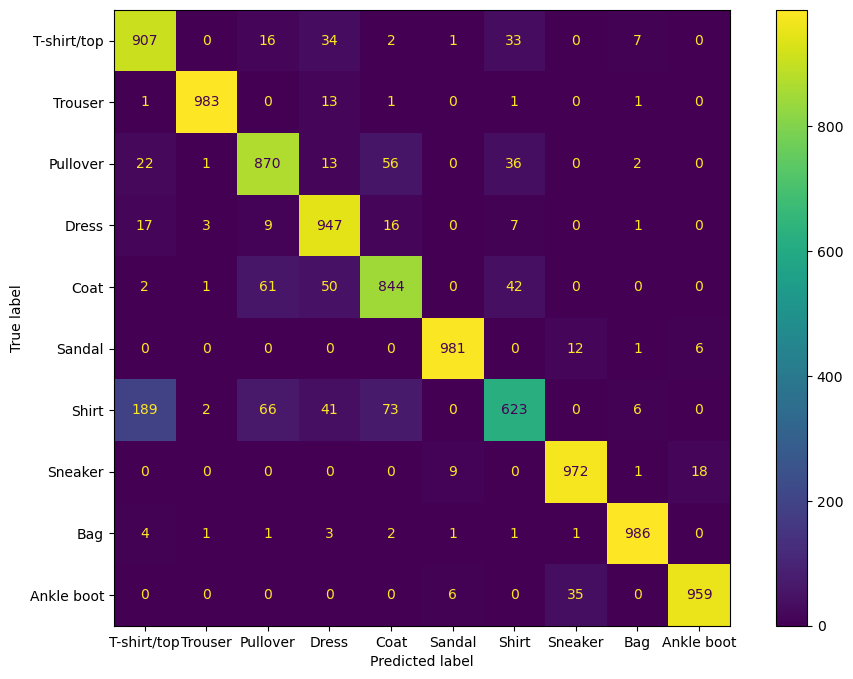

In [37]:
plot_cm(exp_1a)

Errors follow the same trend from the benchmark model. If anything they are exacerbated. The model is probably losing information from all the downsampling.

## Model (B)

In [38]:
exp_1b = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=32,
                  kernel_size=(4, 4),
                  activation="relu",
                  padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),

    # add a second convolution layer
    layers.Conv2D(filters=64,           # increase number of filters...
                  kernel_size=(2, 2),   # ...but reduce window size
                  activation="relu",
                  padding="same"),
    # layers.MaxPool2D(pool_size=(2, 2)), # remove MaxPooling

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

exp_1b.compile(optimizer=keras.optimizers.Adam(),
               loss=keras.losses.SparseCategoricalCrossentropy(),
               metrics=[keras.metrics.sparse_categorical_accuracy]) # just balanced_accuracy

exp_1b_history = exp_1b.fit(
    x=X_train,
    y=y_train,
    validation_split=0.10,
    epochs=20,
    callbacks=make_callbacks()
)

exp_1b_test_loss, exp_1b_test_accuracy = exp_1b.evaluate(X_test, y_test)
model_results.append({
    "name": "Experiment 1b",
    "loss": exp_1b_test_loss,
    "acc": exp_1b_test_accuracy,
    "notes": "add second conv, increase filters, remove max pool"
})

print(f"exp_1 test accuracy: {exp_1b_test_accuracy}")

Epoch 1/20


I0000 00:00:1780109938.134985     934 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_231963__.22


1677/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5547 - sparse_categorical_accuracy: 0.8015

I0000 00:00:1780109945.662999     935 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_231963__.22


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.4035 - sparse_categorical_accuracy: 0.8554 - val_loss: 0.3077 - val_sparse_categorical_accuracy: 0.8907
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2670 - sparse_categorical_accuracy: 0.9031 - val_loss: 0.2632 - val_sparse_categorical_accuracy: 0.9063
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2170 - sparse_categorical_accuracy: 0.9210 - val_loss: 0.2463 - val_sparse_categorical_accuracy: 0.9140
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1788 - sparse_categorical_accuracy: 0.9349 - val_loss: 0.2589 - val_sparse_categorical_accuracy: 0.9123
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1455 - sparse_categorical_accuracy: 0.9480 - val_loss: 0.2619 - val_sparse_categorical_accuracy: 0.9145
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.1196 - sparse_categorical_accuracy: 0.9566 - val_loss: 0.2913 - val_sparse_categorical_accuracy: 0.9120
31

## Visualizations (B)

### Training

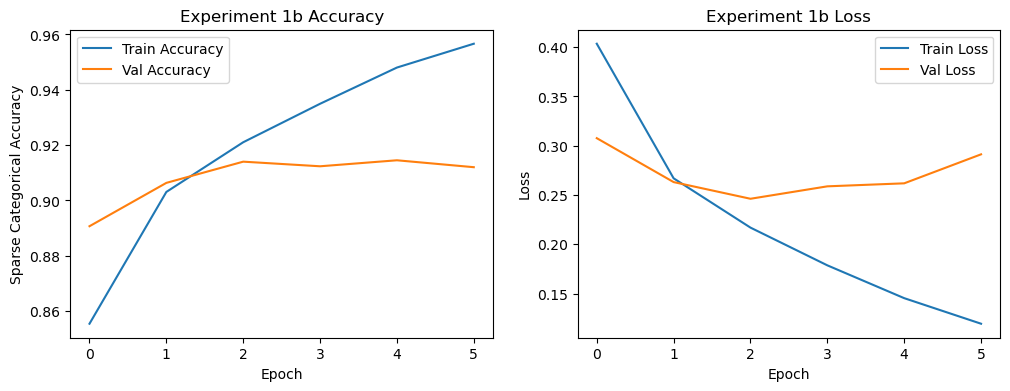

In [39]:
plot_training(exp_1b_history.history, "Experiment 1b")

Seems like this might not be the right direction. Val loss don't really plateau but instead starts rising.

### Tracing Layers

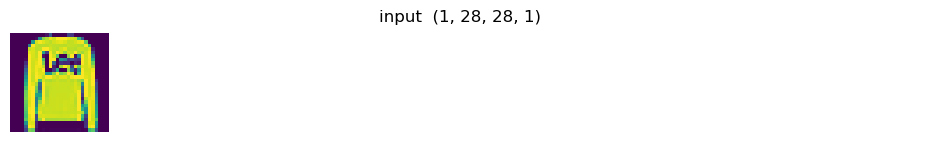

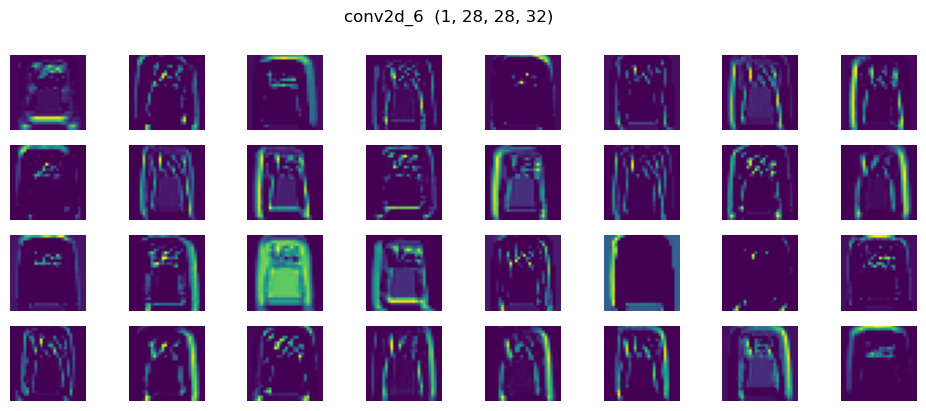

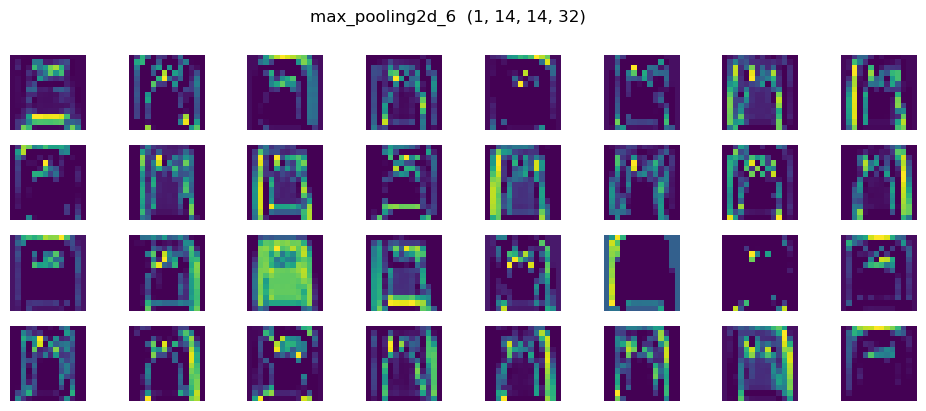

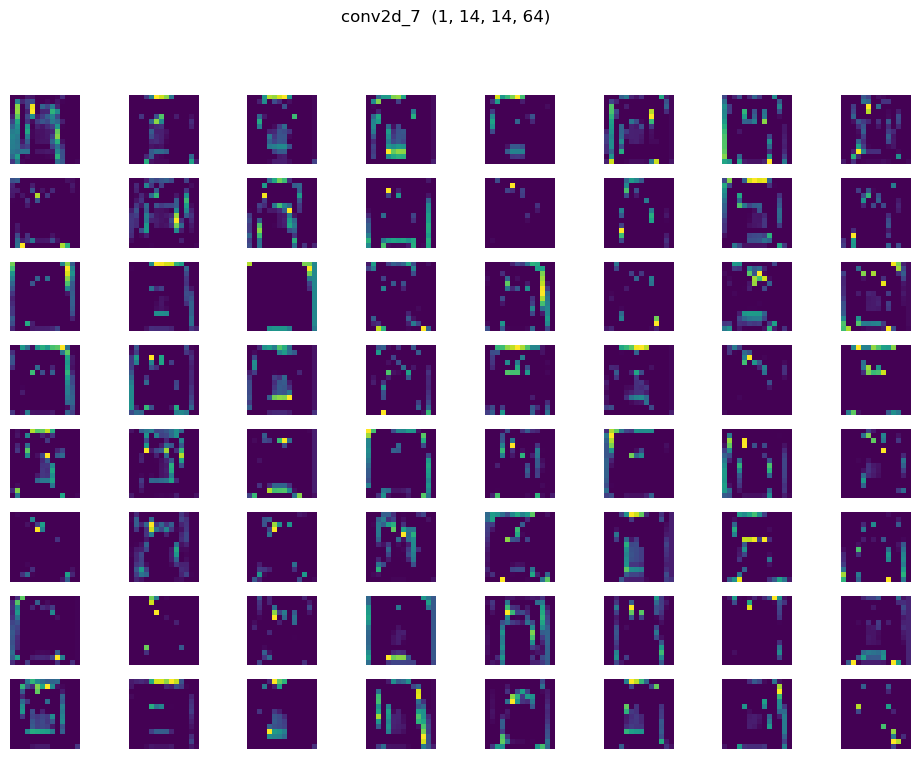

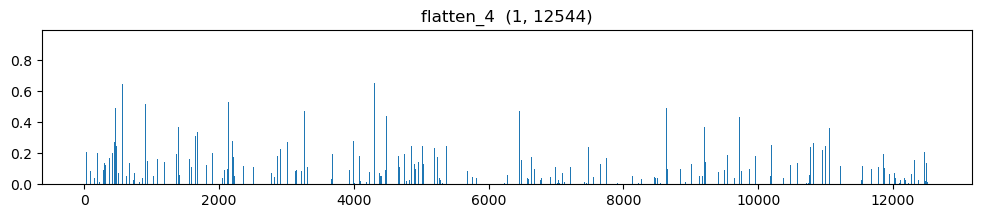

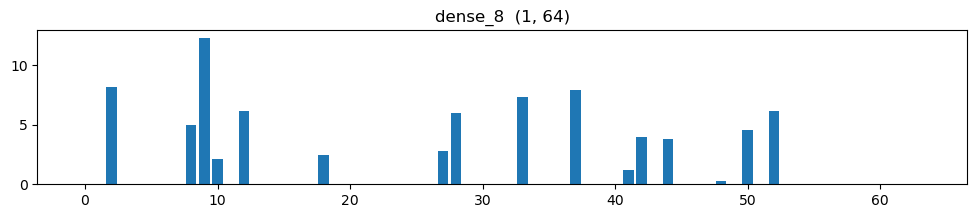

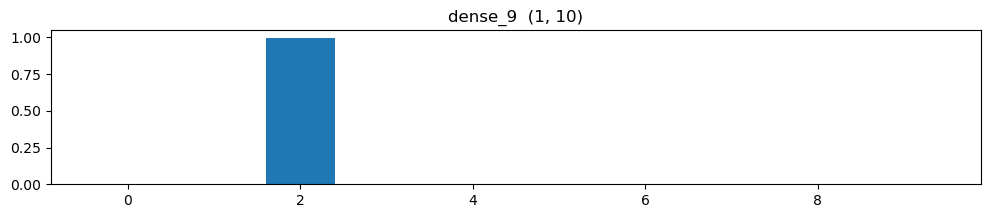

In [40]:
trace_input(sample_pullover, exp_1b)

Just an observation: notice how less neurons fire (and with less signal) in the dense layer before the classification head compared to `exp_1a`

### Errors

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


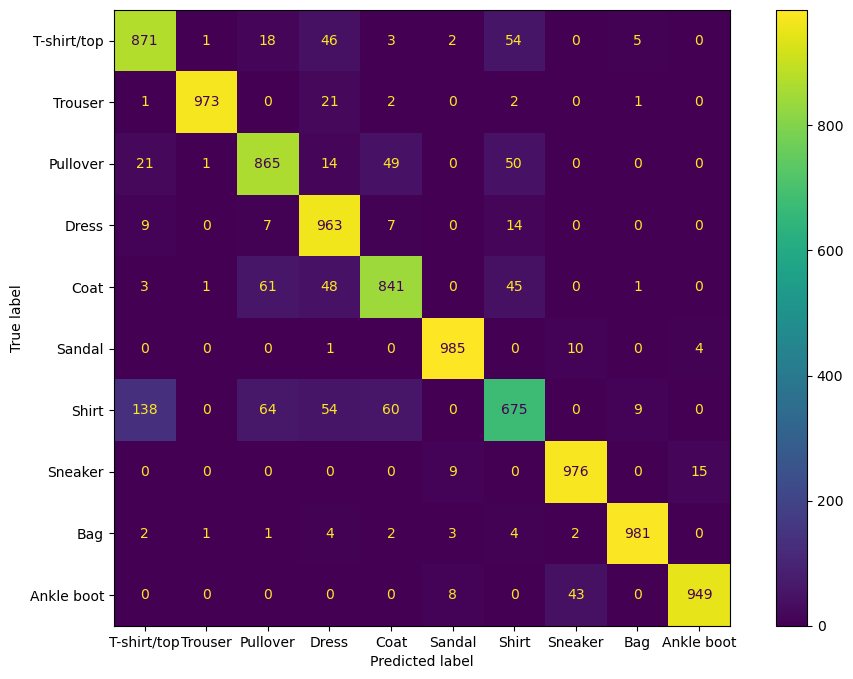

In [41]:
plot_cm(exp_1b)

Problems still carrying over and getting worse.

# Experiment 2: Adding Dropout

The main problem so far has been with overfitting. Dropout might be able to help us out by randomly suppressing neurons after flattening, forcing the model to explore different routes.

## Model (A)

In [42]:
exp_2a = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=32,
                  kernel_size=(4, 4),
                  activation="relu",
                  padding="same"),
    # increase window size to reduce features (helps dropout have more impact)
    layers.MaxPool2D(pool_size=(3, 3)),
    layers.Flatten(),
    layers.Dropout(rate=0.50), # I know this is huge...
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

exp_2a.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.sparse_categorical_accuracy]) # just balanced_accuracy

exp_2a_history = exp_2a.fit(
    x=X_train,
    y=y_train,
    validation_split=0.10,
    epochs=20,
    callbacks=make_callbacks()
)

exp_2a_test_loss, exp_2a_test_accuracy = exp_2a.evaluate(X_test, y_test)
model_results.append({
    "name": "Experiment 2a",
    "loss": exp_2a_test_loss,
    "acc": exp_2a_test_accuracy,
    "notes": "increase max pool window, add dropout"
})

print(f"exp_2a test accuracy: {exp_2a_test_accuracy}")

Epoch 1/20


I0000 00:00:1780109990.717536     933 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_282583__.22


1679/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6659 - sparse_categorical_accuracy: 0.7564

I0000 00:00:1780109997.443639     932 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_282583__.22


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 0.5021 - sparse_categorical_accuracy: 0.8176 - val_loss: 0.3813 - val_sparse_categorical_accuracy: 0.8642
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3613 - sparse_categorical_accuracy: 0.8687 - val_loss: 0.3169 - val_sparse_categorical_accuracy: 0.8853
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3242 - sparse_categorical_accuracy: 0.8809 - val_loss: 0.3431 - val_sparse_categorical_accuracy: 0.8753
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2983 - sparse_categorical_accuracy: 0.8917 - val_loss: 0.3168 - val_sparse_categorical_accuracy: 0.8860
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2812 - sparse_categorical_accuracy: 0.8958 - val_loss: 0.2964 - val_sparse_categorical_accuracy: 0.8912
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2651 - sparse_categorical_accuracy: 0.9013 - val_loss: 0.2781 - val_sparse_categorical_accuracy: 0.8973
Ep

## Visualizations (B)

### Training

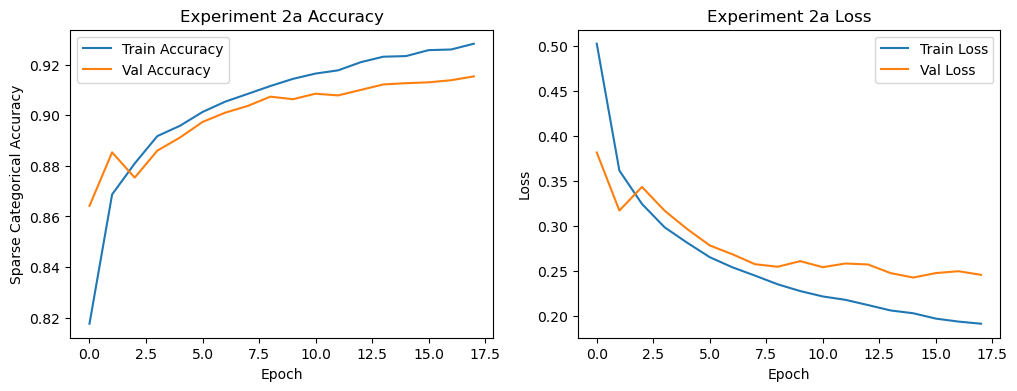

In [43]:
plot_training(exp_2a_history.history, "Experiment 2a")

### Tracing Layers

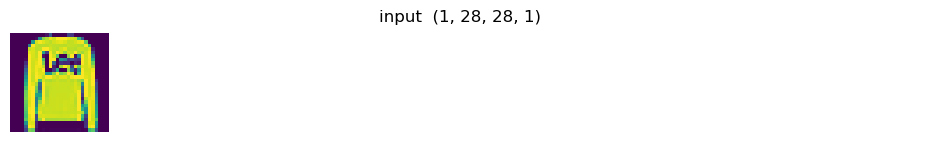

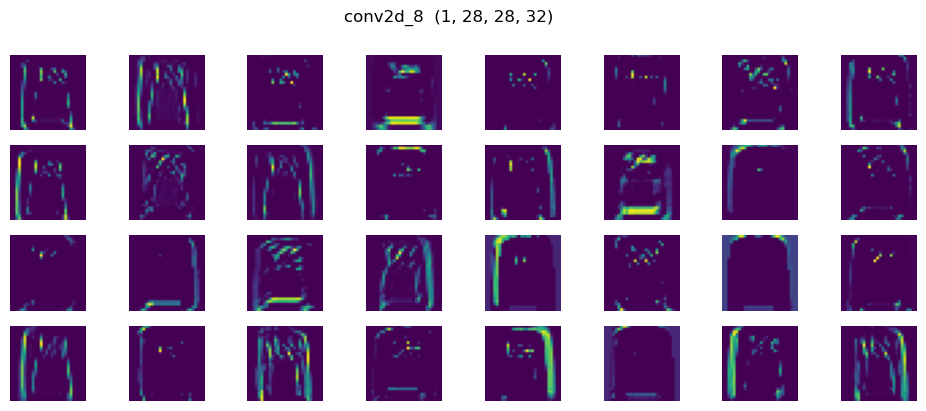

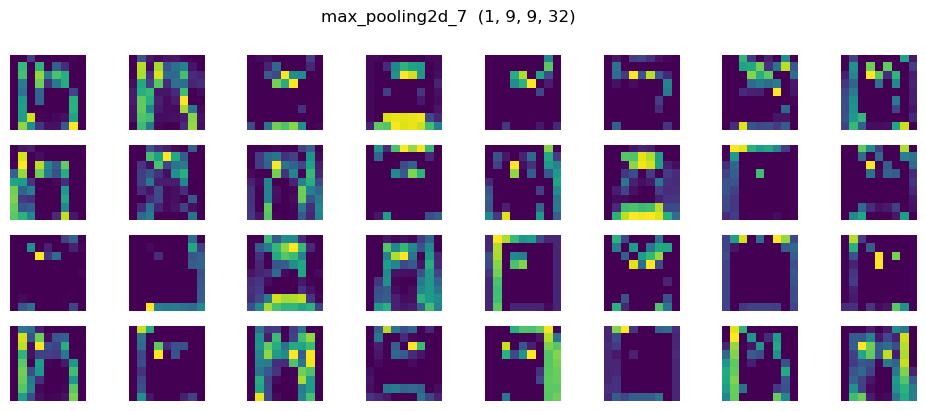

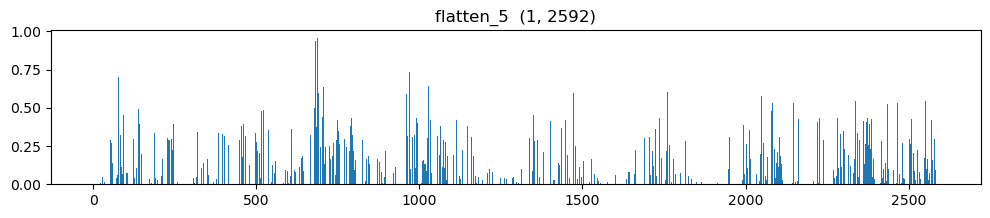

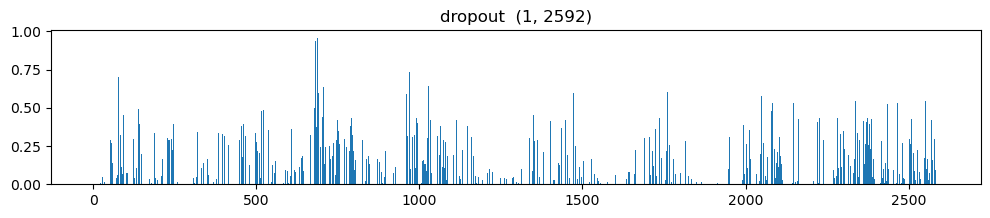

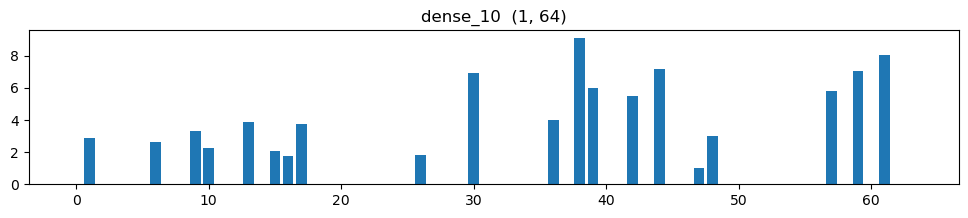

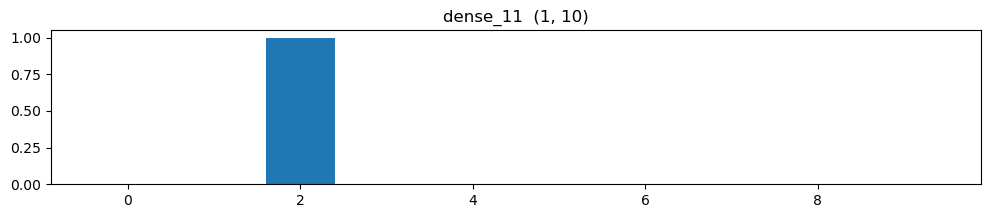

In [44]:
trace_input(sample_pullover, exp_2a)

### Errors

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


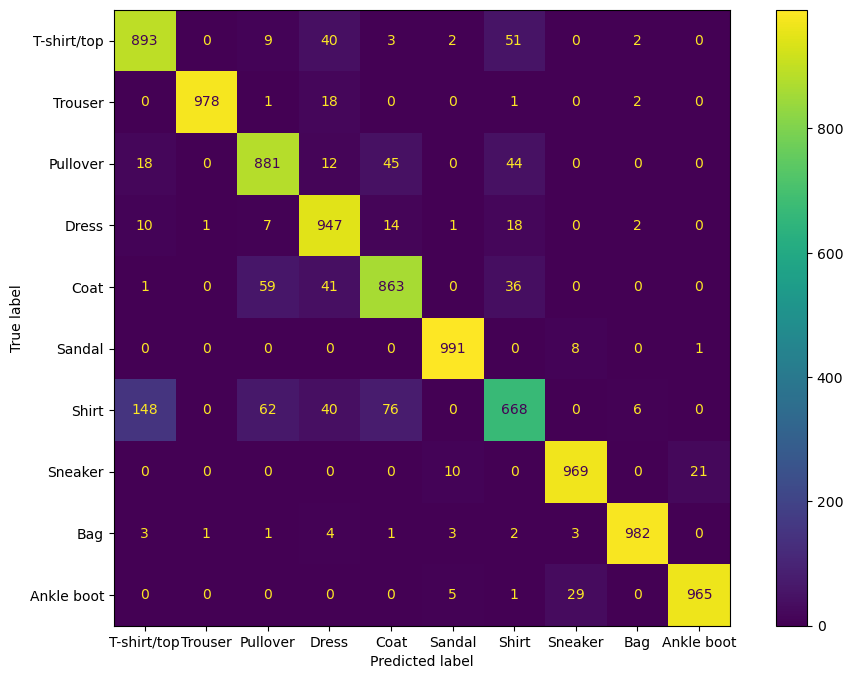

In [47]:
plot_cm(exp_2a)

Dang...Do I have to keep saying it? Same problems, a little worse than the benchmark. I am clearly missing something...

## Model (B)

I won't adjust dropout, but I will reuse `exp_2a` and just add more dense layers. Hopefully this will give the model more time to learn.

In [48]:
exp_2b = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(filters=32,
                  kernel_size=(4, 4),
                  activation="relu",
                  padding="same"),
    # increase window size to reduce features (helps dropout have more impact)
    layers.MaxPool2D(pool_size=(3, 3)),
    layers.Flatten(),          # we will have ~6k features by this point
    layers.Dropout(rate=0.50), # give the model cataracts
    # add some dense layers to funnel signals
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

exp_2b.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.sparse_categorical_accuracy]) # just balanced_accuracy

exp_2b_history = exp_2b.fit(
    x=X_train,
    y=y_train,
    validation_split=0.10,
    epochs=20,
    callbacks=make_callbacks()
)

exp_2b_test_loss, exp_2b_test_accuracy = exp_2b.evaluate(X_test, y_test)
model_results.append({
    "name": "Experiment 2b",
    "loss": exp_2b_test_loss,
    "acc": exp_2b_test_accuracy ,
    "notes": "add 4x dense layers"
})

print(f"exp_2b test accuracy: {exp_2b_test_accuracy}")

Epoch 1/20


I0000 00:00:1780110150.874574     934 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_424481__.25
I0000 00:00:1780110151.872488     934 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1780110153.794350     934 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


1681/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6387 - sparse_categorical_accuracy: 0.7620

I0000 00:00:1780110165.928507     934 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_424481__.25


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - loss: 0.4723 - sparse_categorical_accuracy: 0.8256 - val_loss: 0.3528 - val_sparse_categorical_accuracy: 0.8717
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.3322 - sparse_categorical_accuracy: 0.8778 - val_loss: 0.3087 - val_sparse_categorical_accuracy: 0.8840
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2955 - sparse_categorical_accuracy: 0.8916 - val_loss: 0.3082 - val_sparse_categorical_accuracy: 0.8897
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2696 - sparse_categorical_accuracy: 0.8990 - val_loss: 0.2847 - val_sparse_categorical_accuracy: 0.8960
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.2510 - sparse_categorical_accuracy: 0.9066 - val_loss: 0.2772 - val_sparse_categorical_accuracy: 0.9007
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.2380 - sparse_categorical_accuracy: 0.9116 - val_loss: 0.2596 - val_sparse_categorical_accuracy: 0.9052
Ep

## Visualizations (B)

### Training

In [ ]:
plot_training(exp_2b_history.history, "Experiment 2b")

Not terrible. Model generalizes well early on.

### Tracing Layers

In [ ]:
trace_input(sample_pullover, exp_2b)

### Errors

In [ ]:
plot_cm(exp_2b)

Alright...maybe the model is generalizing too much. It's time to pull out the big guns. Instead of cataracts (dropout), we will give the model hallucinogens (augment data before giving it to the network).

# Experiment 3: Augmentation

## Model (A)

In [49]:
DataAugmentation = models.Sequential([
    layers.RandomRotation(0.05),                # randomly rotate training images
    layers.RandomFlip("horizontal")             # randomly flip images left/right
])

exp_3a = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    DataAugmentation,
    layers.Conv2D(filters=32,
                  kernel_size=(4, 4),
                  activation="relu",
                  padding="same"),
    layers.MaxPool2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

exp_3a.compile(optimizer=keras.optimizers.Adam(),
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=[keras.metrics.sparse_categorical_accuracy]) # just balanced_accuracy

exp_3a_history = exp_3a.fit(
    x=X_train,
    y=y_train,
    validation_split=0.10,
    epochs=20,
    callbacks=make_callbacks()
)

exp_3a_test_loss, exp_3a_test_accuracy = exp_3a.evaluate(X_test, y_test)
model_results.append({
    "name": "Experiment 3a",
    "loss": exp_3a_test_loss,
    "acc": exp_3a_test_accuracy,
    "notes": "add data augmentation"
})

print(f"exp_3a test accuracy: {exp_3a_test_accuracy}")

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 0.5382 - sparse_categorical_accuracy: 0.8081 - val_loss: 0.4214 - val_sparse_categorical_accuracy: 0.8520
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - loss: 0.3845 - sparse_categorical_accuracy: 0.8590 - val_loss: 0.3671 - val_sparse_categorical_accuracy: 0.8700
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.3441 - sparse_categorical_accuracy: 0.8735 - val_loss: 0.3293 - val_sparse_categorical_accuracy: 0.8818
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - loss: 0.3201 - sparse_categorical_accuracy: 0.8837 - val_loss: 0.3287 - val_sparse_categorical_accuracy: 0.8862
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.3000 - sparse_categorical_accuracy: 0.8897 - val_loss: 0.3301 - val_sparse_categorical_accuracy: 0.8875
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - loss: 0.2878 - sparse_categorical_accuracy: 0.8935 - val_loss: 0.3138 - val_sparse_categorical

## Visualizations (A)

### Training

In [ ]:
plot_training(exp_3a_history.history, "Experiment 3a")

Pretty rocky training.

### Tracing Layers

In [ ]:
trace_input(sample_pullover, exp_3a)

Super interesting how even fewer neurons are firing in the dense layer.

### Errors

In [ ]:
plot_cm(exp_3a)

A new problem arrives! Now we are confusing shirts and specifically sneakers. I guess shirts and sneakers both can have a sort of rectangular shape when downsampled (lots of straight lines)...maybe that is what the models are learning? That would explain why shirt types were the main class getting confused.

# Experiment 4: Batch Normalization

At this point I'm throwing the entire kitchen sink. I haven't tried any regularization yet.

## Model

In [50]:
exp_4a = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])
exp_4a.compile(optimizer=keras.optimizers.Adam(),
               loss=keras.losses.SparseCategoricalCrossentropy(),
               metrics=[keras.metrics.sparse_categorical_accuracy]) # just balanced_accuracy

exp_4a_history = exp_4a.fit(
    x=X_train,
    y=y_train,
    validation_split=0.10,
    epochs=20,
    callbacks=make_callbacks()
)

exp_4a_test_loss, exp_4a_test_accuracy = exp_4a.evaluate(X_test, y_test)
model_results.append({
    "name": "Experiment 4a",
    "loss": exp_4a_test_loss,
    "acc": exp_4a_test_accuracy,
    "notes": "add batch norm after conv, add globalmaxpooling, add dropout"
})

print(f"exp_4a test accuracy: {exp_4a_test_accuracy}")

Epoch 1/20


I0000 00:00:1780110503.850094     933 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_651149__.49


1677/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6113 - sparse_categorical_accuracy: 0.7918

I0000 00:00:1780110514.805421     934 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_651149__.49


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.4534 - sparse_categorical_accuracy: 0.8423 - val_loss: 0.3684 - val_sparse_categorical_accuracy: 0.8640
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3021 - sparse_categorical_accuracy: 0.8915 - val_loss: 0.3260 - val_sparse_categorical_accuracy: 0.8818
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2651 - sparse_categorical_accuracy: 0.9047 - val_loss: 0.2519 - val_sparse_categorical_accuracy: 0.9098
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2393 - sparse_categorical_accuracy: 0.9149 - val_loss: 0.4102 - val_sparse_categorical_accuracy: 0.8568
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.2209 - sparse_categorical_accuracy: 0.9215 - val_loss: 0.2485 - val_sparse_categorical_accuracy: 0.9138
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.2051 - sparse_categorical_accuracy: 0.9265 - val_loss: 0.2660 - val_sparse_categorical_accuracy: 0.9023
Ep

Well, it looks like BatchNormalization helps a good amount.

## Visualizations

### Training

In [ ]:
plot_training(exp_4a_history.history, "Experiment 4a")

### Tracing Layers

In [ ]:
trace_input(sample_pullover, exp_4a)

### Errors

In [ ]:
plot_cm(exp_4a)

# Model Comparison

In [51]:
pd.DataFrame(model_results).sort_values("acc", ascending=False)

,name,loss,acc,notes
3,Experiment 2a,0.252652,0.9137,"increase max pool window, add dropout"
4,Experiment 2b,0.265127,0.9133,add 4x dense layers
6,Experiment 4a,0.251985,0.9110,"add batch norm after conv, add globalmaxpoolin..."
2,Experiment 1b,0.264156,0.9079,"add second conv, increase filters, remove max ..."
1,Experiment 1a,0.263017,0.9072,add second conv layer
0,Benchmark,0.279858,0.9028,NaN
5,Experiment 3a,0.303189,0.8994,add data augmentation


The only models to beat the benchmark had dropout and a means of amplifying signals.

# Hyperparameter Tuning

In [52]:
import optuna

/home/austin_muelrath/miniconda3/envs/ml-linux/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [53]:
class OptunaPruningCallback(keras.callbacks.Callback):
    """vibe function to replace a broken optuna implementation of the keras pruner"""
    def __init__(self, trial, monitor="val_sparse_categorical_accuracy"):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        value = logs.get(self.monitor)
        if value is None:
            return
        self.trial.report(value, step=epoch)
        if self.trial.should_prune():
            raise optuna.TrialPruned()

In [54]:
def objective(trial):
    learning_rate   = trial.suggest_float("learning_rate", 2e-5, 1e-2, log=True)
    n_filters_conv1 = trial.suggest_int("filters_conv1", 8, 256)
    n_filters_conv2 = trial.suggest_int("filters_conv2", 8, 256)
    n_filters_conv3 = trial.suggest_int("filters_conv3", 8, 256)   # fixed key
    dropout         = trial.suggest_float("dropout", 0.03, 0.5)

    tune = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),
        layers.Conv2D(n_filters_conv1, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(n_filters_conv2, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(n_filters_conv3, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(), # flattens

        layers.Dropout(dropout),
        layers.Dense(NUM_CLASSES, activation="softmax"),
    ])

    tune.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.sparse_categorical_accuracy],
    )

    callbacks = make_callbacks() + [
         OptunaPruningCallback(trial, "val_sparse_categorical_accuracy")
    ]

    history = tune.fit(
        x=X_train, y=y_train,
        validation_split=0.10,
        epochs=20,
        callbacks=callbacks,
        verbose=0,
    )

    # return VALIDATION accuracy, not test
    return max(history.history["val_sparse_categorical_accuracy"])

In [55]:
study = optuna.create_study(
    direction="maximize",
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=5),
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=100)

[I 2026-05-29 20:09:54,478] A new study created in memory with name: no-name-b1ee8385-3cd6-4078-a0d9-6e5494327d1f
I0000 00:00:1780110596.244912     930 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_739018__.49
I0000 00:00:1780110615.215404     930 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_739018__.49
[I 2026-05-29 20:12:27,036] Trial 0 finished with value: 0.9171666502952576 and parameters: {'learning_rate': 0.00020507019380336982, 'filters_conv1': 244, 'filters_conv2': 190, 'filters_conv3': 157, 'dropout': 0.10332876100794516}. Best is trial 0 with value: 0.9171666502952576.
I0000 00:00:1780110748.367974     933 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_818030__.49
I0000 00:00:1780110758.950401     933 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_818030__.49
[I 2026-05-29 20:14:44,016] Trial 1 finished with value: 0.9243333339691162 and parameters: {'lea

# Final Model

In [56]:
params = study.best_params

In [62]:
final_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(params["filters_conv1"], 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(params["filters_conv2"], 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Conv2D(params["filters_conv3"], 3, padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(params["dropout"]),
    layers.Dense(NUM_CLASSES, activation="softmax"),
])

final_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["learning_rate"]),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=[keras.metrics.sparse_categorical_accuracy],
)


history = final_model.fit(
    x=X_train, y=y_train,
    validation_split=0.10,
    epochs=20,
    callbacks=make_callbacks(),
    verbose=0,
)

final_model_test_loss, final_model_test_accuracy = final_model.evaluate(X_test, y_test)
print(f"final model test acc: {final_model_test_accuracy}")

I0000 00:00:1780119491.691817     930 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7060805__.49
I0000 00:00:1780119507.513093     935 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7060805__.49


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2423 - sparse_categorical_accuracy: 0.9198
final model test acc: 0.9197999835014343


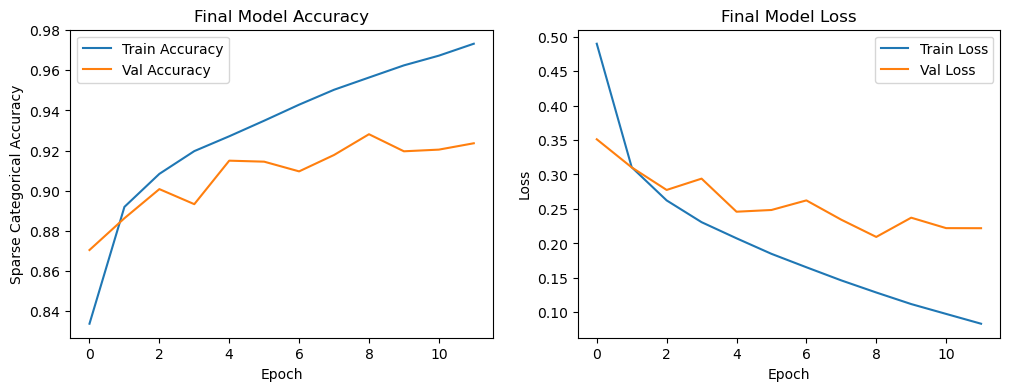

In [63]:
plot_training(history.history, "Final Model")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


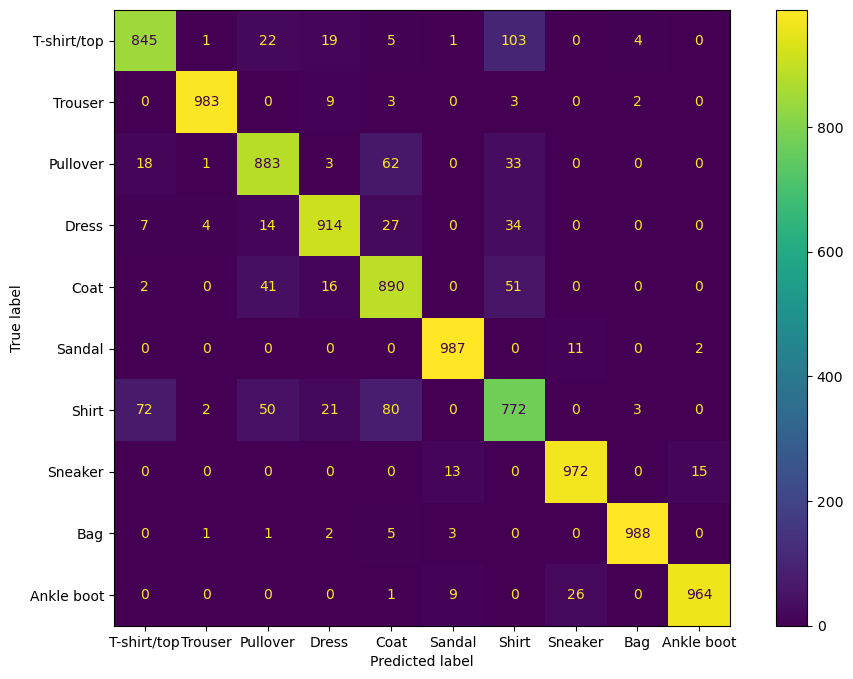

In [65]:
plot_cm(final_model)

# Discussion & Workflow

**Discussion**

The greatest challenge of this notebook was trying to balance stable training with deducing exactly why the model blurred specifically shirts together, while generally performing very well on all other classes.

No progress was really made in the latter issue until the very last model, where upon visualizing BatchNormalization, I noticed that previously small signals (which likely contributed to noise) where entirely cutout. The filtered images were much clearer and this certainly contributed to better model performance.

One other thing I noticed is that better models tended to have sparse activations in the layer before the classification head.

**Workflow**

With CNNs being as complex as they are, and from the perspective of a learner, it really helps build intuition if I can see what actually happens to the inputs at each layer. This is made particularly simple given that this is image classification: I can see exactly what the model sees by visualizing activations at each layer.

So, for each model, I will make some tweaks (whether it be adding layers, changing layer parameters, etc), visualize activations, loss, and errors. This helped me build a quick and relatively holistic view of where my model is working and where it isn't.

When choosing the architecture for the final model, I just picked one which beat the benchmark and had the most stable training.

Finally, we finetune. As I build intuition I can see picking hyperparams being a more surgical task, but for now it's a _shotgun approach_. One important mistake I almost made was evaluating the optuna trials using `X_test` rather than using the `history` and picking the best validation accuracy.

Overall out final model improved to a balanced accuracy of 0.919 from 0.911

